# Unified MDTF/GFDL/NCAR Analysis Notebook Template

Contributors: Taydra Low, Elizabeth Maroon, Lei Huang, Yi-Hung Kuo, Stephen Yeager, Brendan Meyers, Feng Zhu, Teagan King \
Date: 07/1/26


* **Full setup instructions** (git/branch, data, configuration): see
[`natl_ocean_notebook_user_guide.md`](natl_ocean_notebook_user_guide.md).

* View this POD development cheatsheet for additional information:
[POD development cheat sheet](https://github.com/NOAA-GFDL/MDTF-diagnostics/blob/main/doc/sphinx/dev_cheatsheet.rst)

* To run this notebook, create the `mdtf_nb` conda environment and register its kernel (only
needed once). Each POD will need esnb and intake-esm. Any additional packages are POD specific (except ipykernel and esmpyz). To avoid discrepancies with package dependencies, order of operations is important here. If you need to install additional packages, use conda-forge if possible. 
```bash
conda create -n mdtf_nb -c conda-forge python=3.12 xarray scipy pandas numba \
    xesmf esmpy cartopy gsw-xarray xhistogram cf_xarray matplotlib gcsfs ipykernel
conda activate mdtf_nb
pip install esnb "xwmt==0.0.3" cmip_basins intake-esm dask dask-jobqueue netcdf4 cftime
python -m ipykernel install --user --name mdtf_nb --display-name "Python (mdtf_nb)"
```

This notebook runs the `natl_ocean` POD (Maroon et al.) through the ESNB interface on CESM timeslice data.


**Kernel:** `Python (mdtf_nb)` (set via the top-right kernel selector).

In [1]:
# Development mode: constantly refreshes module code
%load_ext autoreload
%autoreload 2

import importlib
import collections
import io, sys, os, copy
import yaml, json

from pathlib import Path
import xarray as xr

# Silence benign xarray warning: _FillValue/missing_value (1e+20) stored
# as both float32 and float64; both decode to NaN as intended.
import warnings
warnings.filterwarnings('ignore', message='.*multiple fill values.*', category=xr.SerializationWarning)

# ======================================================================
# USER CONFIGURATION — the single place to edit site paths for this POD.
# Everything downstream reads these via os.environ; nothing else is hardcoded.
# Set them here (CHANGE ME) or export them in your shell before launching Jupyter;
# setdefault keeps any value already exported.
# ======================================================================
os.environ.setdefault('CODE_ROOT', '/glade/work/taydral/MDTF/MDTF-diagnostics')                       # CHANGE ME: your MDTF-diagnostics repo
os.environ.setdefault('WORK_DIR',  '/glade/work/taydral/MDTF/wkdir/MDTF_output/natl_ocean')           # CHANGE ME: output / work dir
os.environ.setdefault('OBS_DATA',  '/glade/work/taydral/MDTF/inputdata/obs_data/natl_ocean')          # CHANGE ME: POD obs + benchmark reference data (obs_1x1.nc, omip*.nc, obs_wmt*.nc)
os.environ.setdefault('FX_DIR',    '/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Ofx')  # CHANGE ME: areacello/volcello (fx) source dir
os.environ.setdefault('PBS_ACCOUNT', 'UWIS0041')                                                      # CHANGE ME: PBS account (only used if dask=True)
# Conda install root (used by MDTF 'prod' framework mode only) — derived from the active env.
os.environ.setdefault('CONDA_ROOT', os.path.dirname(os.path.dirname(os.environ.get('CONDA_EXE', sys.prefix))))

Path(os.environ['WORK_DIR']).mkdir(parents=True, exist_ok=True)

## About the POD: North Atlantic Ocean diagnostics

Authors: Elizabeth Maroon, Stephen Yeager, Taydra Low, Brenden Meyers, Feng Zhu, Teagan King

This natl_ocean POD evaluates how well climate models represent the subtropical-to-subpolar North Atlantic
ocean state, focusing on:
- Sea surface and upper-200m temperature and salinity climatologies
- Mixed layer depth (MLD)
- Potential density (σ₀)
- Surface heat and freshwater fluxes
- Surface-forced water-mass transformation (WMT) in σ₂ coordinates
- Atlantic Meridional Overturning Circulation (AMOC) streamfunction in σ₂ coordinates
- Bias relative to a 1°×1° observation-based reference (`obs_1x1.nc`)

------------------------------------------
- POD source: `diagnostics/natl_ocean/` (Maroon et al.)
- Helper module: `POD_utils.py` (bias, WMT, and AMOC analysis functions)
- Detailed description: `diagnostics/natl_ocean/doc/natl_ocean.rst`
-------------------------------------------

## Jupyter ESNB notebook POD settings
- This POD requires CMIP6 monthly ocean variables (tos, thetao, so, hfds, vsf, uo, vo) plus fx (areacello, volcello). Optional: umo, vmo for the mass-transport AMOC path.
The POD is built upon the following procedures:
### [Section 1: Prepare POD Settings](#section1)
- Set the parameters of the POD (interactive or read from `settings.jsonc`)
- Set the runtime configurations (machine, dask cluster size)
- Define the model case (CESM timeslice) and date range
- Point at the data catalog and obs / work directories
### [Section 2: Load Metadata from Catalog Files](#section2)
- Two default options available (users can override)
    -  ESNB option (current default)
    - Transition to Intake-ESM (led by Aparna)
- ESNB load for the monthly variables (auto-skips optional umo/vmo if not in catalog)
- Manual `xr.open_dataset` for fx (time-invariant) variables
- Per-variable dispatch into named datasets (`ds_thetao`, `ds_so`, `ds_uo`, `ds_vo`, …); no global merged dataset
- Detect mass-transport availability (`has_mass_transport` flag)
- Load obs
### [Section 3: Diagnostics Computation](#section3)
- Sanity check: compute σ₀ on a small slice
- Steps 1–5: bias-plot path (local merge → preprocess → σ₀/MLD → zavg → regrid → climatology)
- Steps 6–7: WMT path (local surface-field merge → `compute_wmt` lines + maps)
- Step 8: AMOC velocity inputs (per-variable inspection, U-vs-T grid check)
- Step 9: AMOC streamfunction in σ₂ (`POD_utils.calculate_moc` with use_currents auto/override)
### [Section 4: Results Visualization](#section4)
- Bias maps vs obs (θ, S, σ₀, MLD)
- Scatter plot of θ vs S biases
- WMT lines vs OMIP benchmarks (by region)
- Density-flux maps at specified σ₂ classes
- Atlantic AMOC(σ₂) time-mean streamfunction
- WMT + AMOC at 45°N compensation diagnostic
### [Section 5: More about this POD](#section5)
- [Check the .rst file](https://github.com/Taydra-Low/MDTF-diagnostics/blob/feature/taydra-dev/diagnostics/natl_ocean/doc/natl_ocean.rst)

<a id='section1'></a>
## Section 1: Prepare POD Settings

Load from `diagnostics/natl_ocean/settings.jsonc` (`mode == "prod"`) or define inline (`mode == "interactive"`).
We also build a monthly-only copy for ESNB — it can't time-slice the fx vars (`areacello`, `volcello`),
so we load those manually in Section 3.

**Key variables**:
- `mode`: 'interactive' (manual) or 'driver'/'prod' (framework-driven)
- `startdate`, `enddate`: analysis period
- Data: CESM timeslice (native POP output, harmonized to CMIP in-memory)
- `settings_*`: POD-specific options (regrid resolution, etc.)


In [2]:
# Framework: Setup paths to import MDTF code as modules
module_path = os.environ['CODE_ROOT']
print(f"Using MDTF framework version {module_path}")
if module_path not in sys.path:
    sys.path.append(module_path)

# Import python libraries from /src directory
from src import util              # varlist_util, translation, xr_parser, units
from src.util import json_utils

Using MDTF framework version /glade/work/taydral/MDTF/MDTF-diagnostics


 If the mode is `interactive`, the user will manually input the needed info of the POD options, otherwise the info will be read from the default `settings.jsonc` file.

In [3]:
# Define a mode (leave "interactive" for now; "prod" reads settings.jsonc)
mode = "interactive"

# machine: controls whether to spin up a dask PBSCluster.
#   "casper"        — submit a PBS job and use dask-distributed for parallel compute
#   "casper-notdask" — single-process xarray/dask (default; what the rest of the notebook
#                      has been tested against)
machine = "casper"
dask = False
# dask = True


# Data: CESM (cesm_mdtfv3) timeslice — native POP output on the gx1 grid.
#   Files use native names/coords (TEMP/SALT/UVEL/... on z_t in cm, TLONG/TLAT,
#   ULONG/ULAT) and have no tos. Section 2 bypasses ESNB and harmonizes them to
#   CMIP variables/coords/units in-memory (TEMP->thetao, z_t->lev, TLONG/TLAT->lon/lat),
#   derives tos from surface thetao, and applies the CESM/POP2 surface-flux recipe
#   (hfds = SHF + QFLUX; wfo = SFWF - QFLUX/(latent_heat_fusion/1e4)).
#   This frazil correction is CESM-only.

# Verbosity
verbose = True 


### Optional: spin up a dask PBSCluster on Casper

Set `machine = "casper"` in the previous cell to submit a PBS job and use `dask.distributed` for parallel compute. The cluster takes a minute or two to start (check `qstat -u $USER` from a terminal). Set `dask = False` to skip and stay single-process.

In [38]:
# Machine-specific dask setup. Casper PBS via dask-jobqueue.
client = None
cluster = None

if machine == "casper" and dask == True:
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client

    cluster = PBSCluster(
        cores=8,
        memory="32GB",
        account=os.environ['PBS_ACCOUNT'],
        interface="ext",
        job_extra_directives=[],
        walltime="4:00:00",
        queue="casper",
        resource_spec="select=1:ncpus=8:mem=32GB",
    )
    cluster.adapt(minimum_jobs=0, maximum_jobs=1)
    client = Client(cluster)
    print('dask client:', client)
    print('dashboard:', client.dashboard_link)
    # Note: cluster starts via PBS queue — `qstat -u $USER` in a terminal to monitor.
else:
    print(f'machine={machine!r} — skipping dask cluster setup')

# can also use `client = Client()` for a local cluster, but that is not recommended on Casper.

machine='casper' — skipping dask cluster setup


In [5]:
#cluster.close()
#client.close()

### POD settings are defined here (interactive mode) or read from the settings.jsonc file
- settings_dict stores the information needed to run the POD
- If it's interactive mode, user needs to enter each information manually
- Otherwise it can be read in from a settings.jsonc file
- The user can change the time period, latitude range, number of workers
- AdvUser: feel free to define own parameters

In [6]:
# Step 3: Compute thickness-weighted (zavg) means of T, S, σ₀ in upper 200m
# CESM time-range -> 1982-01-01 to 2014-12-31 (33 years)
# startdate, enddate = '1982-01-01', '1982-12-31'

# CESM timeslice -> data available 1995-01-01 to 2015-01-01
startdate, enddate = '1995-01-01', '1995-12-31'

if mode == "interactive":
    settings_full = {
        "settings": {
            # pod_options — natl_ocean-specific knobs (not read by MDTF framework)
            "pod_options": {
                "start_date":    startdate,
                "end_date":      enddate,
                # POD_utils.compute_zavg upper-ocean depth (m)
                "zavg_depth":    200,
                # POD_utils.compute_mld density threshold (kg/m^3) and reference depth (m)
                "mld_dsig":      0.03,
                "mld_rdep":      10.0,
                # POD_utils.regrid target grid (deg) and method
                "regrid_dlon":   1,
                "regrid_dlat":   1,
                "regrid_method": "bilinear",
                # POD_utils.SpatialPlot_climo_bias map region [lon_min, lon_max, lat_min, lat_max]
                "plot_region":   [270, 360, 20, 80],
                "focus_region":  [312, 330, 38, 53],
                "plot_month":    13,   # 13 = annual mean
                "num_workers":   8,
                # WMT (Section 3 Step 6+ / Section 4)
                "wmt_sigma_classes": [35.0, 36.0, 36.5],  # sigma2 levels for compute_wmt MAPS
                "wmt_dsigma":         0.1,                # sigma2 bin width
                "wmt_lat_max":        44,                 # cut to <=lat_max for SPNA WMT
            },
            "runtime_requirements": {"python3": ["matplotlib", "xarray", "xesmf"]},   # None means use the default python version of the MDTF framework
            "driver":      "natl_driver.py",
            "long_name":   "North Atlantic diagnostic in Subtropical to Subpolar latitudes",
            "convention":  "CMIP",
            "description": "North Atlantic Ocean diagnostics",
        },
        "dimensions": {
            "nlat": {"standard_name": "latitude",  "units": "degrees_north", "axis": "Y"},
            "nlon": {"standard_name": "longitude", "units": "degrees_east", "axis": "X"},
            "lev":  {"standard_name": "depth", "units": "centimeters", "axis": "Z", "positive": "down"},
            "time": {"standard_name": "time"},
        },
        "varlist": {
            "tos":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","nlat","nlon"],        "standard_name": "sea_surface_temperature",                  "units": "degC"},
            "vsf":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","nlat","nlon"],        "standard_name": "virtual_salt_flux_into_sea_water",         "units": "kg m-2 s-1", "requirement": "optional"},
            "wfo":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","nlat","nlon"],        "standard_name": "water_flux_into_sea_water",                "units": "kg m-2 s-1", "requirement": "optional"},
            "hfds":      {"frequency": "month", "realm": "ocean", "dimensions": ["time","nlat","nlon"],        "standard_name": "surface_downward_heat_flux_in_sea_water",  "units": "W m-2"},
            "so":        {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_salinity",                       "units": "psu"},
            "thetao":    {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_potential_temperature",          "units": "degC"},
            "uo":        {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_x_velocity",                       "units": "m s-1"},
            "vo":        {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_y_velocity",                       "units": "m s-1"},
            "umo":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "ocean_mass_x_transport",                      "units": "kg s-1", "requirement": "optional"},
            "vmo":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "ocean_mass_y_transport",                      "units": "kg s-1", "requirement": "optional"},
            "volcello":  {"realm": "ocean", "dimensions": ["lev","nlat","nlon"], "standard_name": "ocean_volume", "units": "m3"},
            "areacello": {"realm": "ocean", "dimensions": ["nlat","nlon"],       "standard_name": "cell_area",    "units": "m2"},
        },
    }
else:  # prod mode: read from settings.jsonc (no pod_options block)
    settings_file_path = os.path.join(module_path, "diagnostics/natl_ocean/settings.jsonc")
    try:
        settings_full = json_utils.read_json(settings_file_path)
    except Exception as e:
        print(f"An unexpected error occurred when reading the JSONC file: {e}")

# POD-specific: build a monthly-only copy for ESNB.
# ESNB tries to time-slice every loaded variable; the fx vars (areacello, volcello)
# have no time dim and break .open(). They are loaded manually in Section 3.
settings_monthly = copy.deepcopy(settings_full)
for fx_var in ('areacello', 'volcello'):
    settings_monthly['varlist'].pop(fx_var, None)

# Pre-filter optional vars: ESNB doesn't gracefully skip missing optional vars
# at .open() time — it raises "OSError: no files to open" when no catalog rows
# match. Inspect the catalog and drop any varlist entries marked
# "requirement": "optional" that aren't present. Lets the notebook run on
# models that lack umo/vmo (e.g., CESM2 r1i1p1f1) without changing the
# settings declaration.
import pandas as pd
# The CESM timeslice catalog this notebook loads.
_catalog_name = "CESM_timeslice_ocean_monthly_001.json"
_catalog_json_path = Path(module_path) / "diagnostics/natl_ocean" / _catalog_name
with open(_catalog_json_path) as _f:
    _catmeta = json.load(_f)
# catalog_file in the JSON metadata may be a file:// URL or a bare relative
# filename (CESM timeslice catalog) — strip the prefix and resolve against the JSON dir.
_csv_path = _catmeta['catalog_file']
if _csv_path.startswith('file://'):
    _csv_path = _csv_path[len('file://'):]
if not os.path.isabs(_csv_path):
    _csv_path = str(_catalog_json_path.parent / _csv_path)
_available_vars = set(pd.read_csv(_csv_path)['variable_id'])
for _var, _entry in list(settings_monthly['varlist'].items()):
    if _entry.get('requirement') == 'optional' and _var not in _available_vars:
        settings_monthly['varlist'].pop(_var)
        print(f'Dropped optional var {_var!r} from ESNB load — not in catalog')

print('varlist (ESNB):', list(settings_monthly['varlist'].keys()))
print('varlist (full):', list(settings_full['varlist'].keys()))

Dropped optional var 'vsf' from ESNB load — not in catalog
Dropped optional var 'umo' from ESNB load — not in catalog
Dropped optional var 'vmo' from ESNB load — not in catalog
varlist (ESNB): ['tos', 'wfo', 'hfds', 'so', 'thetao', 'uo', 'vo']
varlist (full): ['tos', 'vsf', 'wfo', 'hfds', 'so', 'thetao', 'uo', 'vo', 'umo', 'vmo', 'volcello', 'areacello']


### The runtime configuration is defined here (interactive mode) or read from the runtime_config.yml file

Defines which simulation(s) to pull from the catalog, the date range, and output paths.

- If running in interactive mode, case settings are entered inline below.
- Otherwise they can be read from a `runtime_config.yml`-style file (not used here).

In [7]:
if mode == "interactive":
    # CESM timeslice catalog + case label.
    _catalog   = "CESM_timeslice_ocean_monthly_001.json"
    _case_name = "CESM-mdtfv3_timeslice_r1i1p1f1"

    case_info = {
        "case_list": {
            _case_name: {
                "model": "CESM", "convention": "CMIP",
                "startdate": startdate, "enddate": enddate,
            }
        },
        "DATA_CATALOG":   str(Path(module_path) / "diagnostics/natl_ocean" / _catalog),
        "OBS_DATA_ROOT":  str(Path(os.environ["OBS_DATA"]).parent),
        "WORK_DIR":       os.environ["WORK_DIR"],
        "OUTPUT_DIR":     os.environ["WORK_DIR"],
        "conda_root":     os.environ["CONDA_ROOT"],
        "conda_env_root": os.path.join(os.environ["CONDA_ROOT"], "envs"),
        "micromamba_exe": "", 
        "large_file": False,
        "make_multicase_figure_html": False, 
        "make_variab_tar": False,
        "overwrite": True, 
        "pod_list": ["natl_ocean"],
        "run_pp": True, 
        "save_pp_data": True,
        "save_ps": False,
        "translate_data": True, 
        "user_pp_scripts": [""],
    }
else:
    # natl_ocean doesn't ship a runtime_config.yml; if you wire one up, load it here.
    case_input_file = os.path.join(module_path, "runtime_config_casper.jsonc")
    print(f"Reading case info from {case_input_file}")
    case_info = json_utils.read_json(case_input_file)

print("Data source: CESM timeslice")
print(f"Catalog: {case_info['DATA_CATALOG']} (exists: {Path(case_info['DATA_CATALOG']).exists()})")


Data source: CESM_timeslice
Catalog: /glade/work/taydral/MDTF/MDTF-diagnostics/diagnostics/natl_ocean/CESM_timeslice_ocean_monthly_001.json (exists: True)


<a id='section2'></a>
## Section 2: Load Metadata from Catalog files

**Framework responsibility**: This section uses the ESNB library (Enhanced Jupyter Notebook-based framework) to load data from intake-esm catalogs.

**What happens here**:
1. ESNB opens the intake-esm catalog (JSON file)
2. Queries for required variables (thetao, so, uo, vo, etc.)
3. Loads NetCDF files into xarray Datasets
4. Handles optional variables gracefully

**Note**: When running via the MDTF framework, this section is skipped. The framework handles preprocessing instead and provides preprocessed data to the POD driver.

**CESM timeslice**: native POP output (not CMORized); Section 2 bypasses ESNB and harmonizes to CMIP names/coords/units in-memory.


**NOTE**: The ESNB library and its functions are only used in this section. Currently only two functions are needed for this POD: `NotebookDiagnostic` and `CaseGroup2`. Users also have the option to use [intake-ESM](https://intake-esm.readthedocs.io/en/stable/) functions.


In [8]:
# Import ESNB library and necessary functions
import esnb
from esnb import NotebookDiagnostic, CaseGroup2

### Initialize the diagnostic and an MDTF case

In [10]:
# ---- Load per-variable datasets (Section 2 core) ----
# CESM timeslice: native POP output (not CMORized) -> harmonize to CMIP variables/
# coords in-memory via POD_utils.load_native_timeslice() and bypass ESNB (which
# requires CMIP names in-file). Produces `loaded_datasets`: a list of single-variable
# datasets that the per-variable dispatch cell below consumes.
#
# POD_utils is imported in full below (cell with pod_dir/sys.path setup); make it
# importable here too since this load cell runs first.
_pod_dir = Path(module_path) / 'diagnostics/natl_ocean'
if str(_pod_dir) not in sys.path:
    sys.path.append(str(_pod_dir))
import POD_utils
loaded_datasets = POD_utils.load_native_timeslice(
    case_info['DATA_CATALOG'],
    settings_monthly['varlist'].keys(),
    startdate, enddate,
)
print(f'Harmonized {len(loaded_datasets)} native timeslice variables to CMIP names: '
      f'{[list(d.data_vars)[0] for d in loaded_datasets]}')

mapping (CMIP -> native): {'thetao': 'TEMP', 'so': 'SALT', 'hfds': 'SHF', 'hfsifrazil': 'QFLUX', 'wfo': 'SFWF', 'uo': 'UVEL', 'vo': 'VVEL'}


/glade/derecho/scratch/taydral/tmp/ipykernel_73482/69014526.py:61: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(rows.iloc[0]['path'], chunks={'time': 1})  # lazy/dask
/glade/derecho/scratch/taydral/tmp/ipykernel_73482/69014526.py:61: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(rows.iloc[0]['path'], chunks={'time': 1})  # lazy/dask
/glade/derecho/scratch/taydral/tmp/ipykernel_73482/69014526.py:61: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(rows.iloc[0]['path'], chunks={'time': 1})  # lazy/dask


Harmonized 7 native timeslice variables to CMIP names: ['thetao', 'so', 'hfds', 'wfo', 'uo', 'vo', 'tos']


### POD-specific: manual load for fx (time-invariant) variables

ESNB's `.open()` time-slices every dataset by `date_range`, which errors on `areacello` and `volcello` since they have no time dim. We open those files directly with `xr.open_dataset` and include them in the merge below.

In [11]:
# fx (time-invariant) vars: areacello (cell area) and volcello (cell volume).
# Loaded manually because ESNB time-slices everything. FX_DIR points at the CMIP6
# Ofx directory; the CESM gx1 timeslice grid matches the CESM2 gx1 grid, so the
# CESM2 gx1 Ofx files serve the timeslice run.
fx_base = Path(os.environ['FX_DIR'])
ds_areacello = xr.open_dataset(fx_base / 'areacello/gn/v20190308/areacello_Ofx_CESM2_historical_r1i1p1f1_gn.nc')
ds_volcello  = xr.open_dataset(fx_base / 'volcello/gn/v20190308/volcello_Ofx_CESM2_historical_r1i1p1f1_gn.nc')
print(f'fx vars loaded: areacello {dict(ds_areacello.sizes)}, volcello {dict(ds_volcello.sizes)}')

fx vars loaded: areacello {'nlat': 384, 'nlon': 320, 'vertices': 4}, volcello {'lev': 60, 'nlat': 384, 'nlon': 320, 'vertices': 4, 'd2': 2}


### Merge all data to create a single xarray dataset including all required variables for computations in Section 3

In [12]:
# Per-variable dispatch: keep each ESNB-loaded variable in its own xarray.Dataset
# instead of merging into ds_merged. This is required for downstream AMOC code
# (Sub2Sub's calculate_moc takes separate ds_t, ds_u, ds_v inputs), and avoids
# the T-grid / U-grid coord-conflict that an xr.merge of tracers + velocities
# would produce.
ds_by_var = {}
for ds in loaded_datasets:
    # Each ESNB-returned dataset wraps exactly one main variable. Find which
    # one and stash the dataset under that name. Order in the tuple is
    # arbitrary — break on the first match per dataset.
    for v in ('thetao', 'so', 'uo', 'vo', 'umo', 'vmo', 'tos', 'hfds', 'vsf', 'wfo'):
        if v in ds.data_vars:
            ds_by_var[v] = ds
            break

# Required variables — fail loudly if any are missing from the ESNB load
ds_thetao = ds_by_var['thetao']   # T-grid 4D (time, lev, nlat, nlon), degC
ds_so     = ds_by_var['so']       # T-grid 4D, psu
ds_uo     = ds_by_var['uo']       # U-grid 4D, m s-1
ds_vo     = ds_by_var['vo']       # U-grid 4D, m s-1
ds_tos    = ds_by_var['tos']      # T-grid 3D surface (time, nlat, nlon)
ds_hfds   = ds_by_var['hfds']     # T-grid 3D surface, W m-2
# Surface freshwater forcing: CESM has vsf (virtual salt flux); most CMIP models
# have wfo (freshwater flux). Load whichever is present (at least one required);
# prefer wfo when both exist. ds_fwflux is the single handle used downstream.
ds_vsf    = ds_by_var.get('vsf')  # T-grid 3D surface, kg m-2 s-1 (CESM); else None
ds_wfo    = ds_by_var.get('wfo')  # T-grid 3D surface, kg m-2 s-1 (CMIP);  else None
if ds_vsf is None and ds_wfo is None:
    raise KeyError('Need vsf or wfo for the WMT freshwater forcing; loaded neither')
ds_fwflux  = ds_wfo if ds_wfo is not None else ds_vsf
fwflux_var = 'wfo' if ds_wfo is not None else 'vsf'

# Optional variables — None if the model doesn't output mass transport
# (e.g., CESM2 r1i1p1f1 only has uo/vo). The AMOC code will fall back to
# velocity inputs in that case.
ds_umo    = ds_by_var.get('umo')
ds_vmo    = ds_by_var.get('vmo')

# ds_areacello and ds_volcello are loaded manually in cell 28 (fx vars
# can't go through ESNB because it time-slices everything).

# Detect mass-transport availability — this flag drives the if-check in the
# AMOC integration (use_currents=True with uo/vo, False with umo/vmo).
has_mass_transport = ds_umo is not None and ds_vmo is not None
if has_mass_transport:
    print('umo/vmo available — AMOC code can use mass-transport inputs (use_currents=False)')
else:
    print('umo/vmo NOT available — AMOC code will fall back to uo/vo velocity (use_currents=True)')

# Inventory print for sanity
print(f'  loaded tracers:   thetao, so, tos, hfds, {fwflux_var}')
print(f'  loaded velocity:  uo, vo')
print(f'  loaded mass-tpt:  {"umo, vmo" if has_mass_transport else "(none)"}')

umo/vmo NOT available — AMOC code will fall back to uo/vo velocity (use_currents=True)
  loaded tracers:   thetao, so, tos, hfds, wfo
  loaded velocity:  uo, vo
  loaded mass-tpt:  (none)


### Open the comparison datasets


Also open all of the comparison data (OMIP)

In [13]:
ds_obs = xr.open_dataset(os.path.join(os.environ['OBS_DATA'], 'obs_1x1.nc')).load()
print(f'obs vars: {list(ds_obs.data_vars)}')
print(f'obs dims: {dict(ds_obs.sizes)}')

obs vars: ['thetao_zavg', 'so_zavg', 'sigma0_zavg', 'sic', 'mld']
obs dims: {'month': 12, 'lat': 180, 'lon': 360}


<a id='section3'></a>
## Section 3: Diagnostics Computation (9 Steps)

**POD-specific logic**: This section contains all the physics calculations specific to the natl_ocean POD. The logic is independent of the data source — the same steps work for CESM2, CESM timeslice, or any model, provided inputs are preprocessed coordinates and 3D fields.

Mirrors `diagnostics/natl_ocean/natl_driver.py` Parts 1–3, plus the AMOC code. Each step calls a function in `POD_utils.py` (imported in Section 2) using values from the `pod_options` block defined in Section 1.

**Workflow**:
- **Step 1**: Preprocess coordinates → standardize dimension names
- **Step 2**: Compute σ₀ (potential density) and MLD (mixed layer depth)
- **Step 3**: Depth-average T, S, σ₀ over the upper 200m
- **Step 4**: Regrid to a regular 1°×1° lat-lon grid
- **Step 5**: Monthly climatology
- **Step 6**: Prepare surface fluxes for WMT forcing
- **Step 7**: Water Mass Transformation (WMT) in σ₂ coordinates
- **Step 8**: Prepare velocity fields for AMOC
- **Step 9**: AMOC streamfunction in σ₂ coordinates

These map to three paths: **Steps 1–5** bias path, **Steps 6–7** WMT path, **Steps 8–9** AMOC path.


In [14]:
pod_dir = Path(module_path) / 'diagnostics/natl_ocean'
if str(pod_dir) not in sys.path:
    sys.path.append(str(pod_dir))

import POD_utils

# Shortcut for the natl_ocean knobs defined in Section 1
opts = settings_full['settings']['pod_options']
print('pod_options keys:', list(opts.keys()))

pod_options keys: ['start_date', 'end_date', 'zavg_depth', 'mld_dsig', 'mld_rdep', 'regrid_dlon', 'regrid_dlat', 'regrid_method', 'plot_region', 'focus_region', 'plot_month', 'num_workers', 'wmt_sigma_classes', 'wmt_dsigma', 'wmt_lat_max']


In [1]:
# get rid of this
#Force-reload POD_utils so edits to POD_utils.py always take effect, even if
# %autoreload silently stops tracking the module mid-session. Re-run this cell
# after editing POD_utils.py, then re-run the cells that use it.
import importlib
import POD_utils
importlib.reload(POD_utils)
print('reloaded POD_utils from', POD_utils.__file__)

ModuleNotFoundError: No module named 'POD_utils'

### Sanity check — compute σ₀ on a small CESM slice

In [16]:
# Sanity check: compute σ₀ on a small (5 levels × 20×20 cells) North Atlantic
# slice from the first month. Verifies compute_sigma0 works on the per-variable
# datasets the same way it did on ds_merged. Expected ~19.8 kg/m³ for this slice.
slice_kwargs = dict(time=0, lev=slice(0, 5), nlat=slice(300, 320), nlon=slice(50, 70))
tiny_t = ds_thetao.isel(**slice_kwargs)
tiny_s = ds_so.isel(**slice_kwargs)
sigma0 = POD_utils.compute_sigma0(tiny_t['thetao'], tiny_s['so'])
print(f'sigma0 shape {sigma0.shape}, mean {float(sigma0.mean()):.3f} kg/m^3')

sigma0 shape (5, 20, 20), mean 19.560 kg/m^3


### Step 1: Preprocess coords + compute layer thickness `dz`

`dz = volcello / areacello` gives per-cell layer thickness. `lev` is converted from cm to m so `POD_utils.compute_zavg` can subset by depth in meters.

In [17]:
# Local merge for the bias path: combine the T-grid tracers + fx vars into a
# single dataset that POD_utils.preprocess_coords and the downstream zavg/regrid
# functions expect. Per-variable datasets are kept globally; this merge is
# scoped to the bias section. Velocity vars (uo/vo, U-grid) are excluded —
# they would conflict on lat/lon coord values.
ds_bias = xr.merge(
    [ds_thetao, ds_so, ds_hfds, ds_fwflux, ds_tos, ds_areacello, ds_volcello],
    join='outer',
)

# preprocess_coords renames POP-style dim names (nlat/nlon -> y/x, etc.) and
# converts depth units. Unify chunks before rechunk so xr.apply_ufunc (used by
# compute_sigma0/compute_mld below) sees consistent dask chunks.
ds_target = POD_utils.preprocess_coords(ds_bias)
ds_target = ds_target.unify_chunks().chunk({'lev': -1})

# dz = per-cell layer thickness, derived from volcello (cell volume) / areacello
# (cell area). Built directly from the per-variable fx datasets — no need to
# go through ds_bias.
dz = ds_volcello['volcello'] / ds_areacello['areacello']
if 'lev' not in dz.coords:
    dz = dz.assign_coords(lev=ds_volcello['lev'])
# The CESM timeslice fx files report lev in cm; convert to m so compute_zavg
# can subset by depth in meters.
dz = dz.assign_coords(lev=dz.lev / 100.0)

print('dz dims:', dict(dz.sizes))
print('ds_target dims:', dict(ds_target.sizes))

dz dims: {'lev': 60, 'nlat': 384, 'nlon': 320}
ds_target dims: {'time': 12, 'lev': 60, 'y': 384, 'x': 320, 'vertices': 4, 'bnds': 2}


In [35]:
nz = dz.sizes['lev']
corner = int((dz[:, 0, 0] > 0).sum())
deep   = int((dz[:, dz.sizes['nlat']//2, dz.sizes['nlon']//2] > 0).sum())
print(f'corner [0,0]: {corner}/{nz} levels nonzero | mid-ocean: {deep}/{nz}')


corner [0,0]: 60/60 levels nonzero | mid-ocean: 60/60


### Step 2: Compute σ₀ and MLD

Uses `pod_options.mld_dsig` (density threshold) and `pod_options.mld_rdep` (reference depth).

In [18]:
# Step 2: Compute potential density (σ₀) and mixed layer depth (MLD)
ds_target['sigma0'] = POD_utils.compute_sigma0(ds_target['thetao'], ds_target['so'])
ds_target['mld']    = POD_utils.compute_mld(ds_target['sigma0'], dsig=opts['mld_dsig'], rdep=opts['mld_rdep'])

print(f"sigma0 mean: {float(ds_target.sigma0.mean()):.3f} kg/m^3")
print(f"mld mean:    {float(ds_target.mld.mean()):.3f} m")

sigma0 mean: 26.261 kg/m^3
mld mean:    60.746 m


### Step 3: Upper-200m thickness-weighted means of θ, S, σ₀

Calls `POD_utils.compute_zavg(ds_target, var, dz, depth=opts['zavg_depth'])` for each var, then drops the full-depth 3D fields so `regrid` doesn't have to ship the heavy 4D arrays.

In [19]:
# Step 3: Compute thickness-weighted (zavg) means of T, S, σ₀ in upper 200m
zavg_vars = ['thetao', 'so', 'sigma0']
for var in zavg_vars:
    ds_target = POD_utils.compute_zavg(ds_target, var, dz, depth=opts['zavg_depth'])
ds_target = ds_target.drop_vars(zavg_vars)

print('after zavg, vars:', sorted(list(ds_target.data_vars)))

after zavg, vars: ['areacello', 'hfds', 'lat_bnds', 'lev_bnds', 'lon_bnds', 'mld', 'sigma0_zavg', 'so_zavg', 'thetao_zavg', 'tos', 'volcello', 'wfo']


### Step 4: Regrid to lat-lon

Uses `pod_options.regrid_dlon`, `regrid_dlat`, and `regrid_method` (default 1°×1° bilinear).

In [20]:
# Step 4: Regrid to regular 1°×1° lat-lon grid for comparison with observations
ds_target = POD_utils.regrid(
    ds_target,
    dlon=opts['regrid_dlon'],
    dlat=opts['regrid_dlat'],
    method=opts['regrid_method'],
)
print('after regrid, dims:', dict(ds_target.sizes))

after regrid, dims: {'time': 12, 'lat': 180, 'lon': 360, 'vertices': 4, 'lev': 60}


### Step 5: Monthly climatology + tag with model name

Collapses the time axis to a 12-month climatology and adds a `model` scalar coordinate so downstream plots can label the data.

In [21]:
model_name = next(iter(case_info['case_list']))
ds_target = ds_target.groupby('time.month').mean('time', keep_attrs=True)
ds_target = ds_target.assign_coords({'model': model_name})

# Materialize into memory: the climatology is small (12 months x 180 x 360),
# and POD_utils.SpatialPlot_climo_bias calls xr.apply_ufunc without dask support.
ds_target = ds_target.load()

print('climatology dims:', dict(ds_target.sizes))
print('model_name:', model_name)

climatology dims: {'month': 12, 'lat': 180, 'lon': 360, 'vertices': 4, 'lev': 60}
model_name: CESM-mdtfv3_timeslice_r1i1p1f1


### Step 6: Prepare surface fields for WMT (Surface-Forced Water Mass Transformation)

Mirrors `natl_driver.py:280-298`. WMT requires a different chunking and surface-only fields, so we build a fresh `ds_target_wmt` via a local merge of the per-variable T-grid datasets (`ds_tos`, `ds_hfds`, `ds_vsf`, `ds_areacello`, plus surface `so`) rather than reusing `ds_target` from the bias-plot path. Region is cut to lat ≤ `pod_options.wmt_lat_max` for compute efficiency.

In [22]:
import numpy as np

# Local merge for the WMT path: only the surface T-grid vars xwmt needs
# (surface temp, surface heat flux, virtual salt flux, cell area). Per-variable
# isolation pattern means we explicitly pick the [[var]] subset from each
# dataset rather than slicing a pre-merged ds_merged.
ds_target_wmt = xr.merge(
    [ds_tos[['tos']], ds_hfds[['hfds']], ds_fwflux[[fwflux_var]], ds_areacello[['areacello']]],
    join='outer',
).copy()

# Surface salinity: take the top model level of so and drop the lev coord so
# the result lives on the same 2D (time, nlat, nlon) grid as the other WMT
# inputs. xwmt expects sos as a surface variable.
ds_target_wmt['sos'] = ds_so['so'].isel(lev=0).drop_vars('lev')

# Rename POP-style dim names to xwmt's expected y/x
ds_target_wmt = ds_target_wmt.rename({'nlat': 'y', 'nlon': 'x'})

# Restrict to subpolar latitudes (lat <= wmt_lat_max). Mirrors the driver's
# y-slice trick: find the max y-index where lat < threshold across all x, then
# slice [miny:maxy]. Cuts the array down for compute efficiency since WMT
# only cares about the SPNA region.
miny = ds_target_wmt['y'].where(ds_target_wmt['lat'] < opts['wmt_lat_max']).max('y').min('x')
maxy = ds_target_wmt['y'].max('y')
ds_target_wmt = ds_target_wmt.sel(y=slice(miny, maxy))

# Rechunk for xwmt.swmt: x/y as single chunks, time as per-step chunks (one
# month per chunk). The xwmt loop iterates over time, so per-step chunks let
# dask parallelize across timesteps.
ds_target_wmt = ds_target_wmt.unify_chunks().chunk({'y': -1, 'x': -1, 'time': 1})
print('ds_target_wmt vars:', list(ds_target_wmt.data_vars))
print('ds_target_wmt dims:', dict(ds_target_wmt.sizes))

ds_target_wmt vars: ['tos', 'hfds', 'wfo', 'areacello', 'sos']
ds_target_wmt dims: {'time': 12, 'y': 90, 'x': 320}


### Step 7: Compute WMT in σ₂ coordinates

Two calls to `POD_utils.compute_wmt` — one for lines (sum over region, mean over time) and one for maps at the σ₂ classes set in `pod_options.wmt_sigma_classes`.

In [23]:
# Step 4: Regrid to regular 1°×1° lat-lon grid for comparison with observations
sigma_classes = np.array(opts['wmt_sigma_classes'])
dsigma = opts['wmt_dsigma']

# Lines: WMT vs sigma2, summed over each SPNA region, time-averaged
ds_wmt_lines = POD_utils.compute_wmt(ds_target_wmt, 'WMT', 'sigma2', dsigma)
ds_wmt_lines = ds_wmt_lines.mean('time')
print('ds_wmt_lines dims:', dict(ds_wmt_lines.sizes))

# Maps: surface density flux at each sigma class
ds_wmt_maps = POD_utils.compute_wmt(
    ds_target_wmt, 'MAPS', 'sigma2', dsigma,
    dclasses=sigma_classes,
)

# Regrid the model maps from the native curvilinear grid onto a regular 1deg x 1deg
# lat-lon grid (POD_utils.regrid defaults to a 1x1 global grid) so they sit on the
# same grid as the 1x1 obs benchmark before plotting. compute_wmt returns a
# DataArray, so wrap/unwrap through a Dataset for the regridder.
ds_wmt_maps = POD_utils.regrid(ds_wmt_maps.to_dataset(name='wmt'))['wmt']
print('ds_wmt_maps dims:', dict(ds_wmt_maps.sizes))

<xarray.Dataset> Size: 74kB
Dimensions:  (region: 7, time: 12, sigma2: 54)
Coordinates:
  * region   (region) <U23 644B 'Labrador Sea' ... 'Subpolar North Atlantic'
  * time     (time) object 96B 1995-01-16 13:00:00.000001 ... 1995-12-16 12:0...
  * sigma2   (sigma2) float64 432B 33.15 33.25 33.35 33.45 ... 38.25 38.35 38.45
Data variables:
    heat     (region, time, sigma2) float64 36kB dask.array<chunksize=(1, 1, 54), meta=np.ndarray>
    salt     (region, time, sigma2) float64 36kB dask.array<chunksize=(1, 1, 54), meta=np.ndarray>
ds_wmt_lines dims: {'region': 7, 'sigma2': 54}
[35.  36.  36.5] 3
35.0
36.0
36.5
ds_wmt_maps dims: {'time': 12, 'sigma2': 3, 'lat': 180, 'lon': 360}


### Step 8: AMOC velocity inputs (U-grid)

Inspect the per-variable velocity datasets that the upcoming AMOC code will consume. `calculate_moc(ds_t, ds_u, ds_v, use_currents=...)` takes its u and v inputs as separate single-variable datasets that might be on different grids, so we do **not** merge them here.

`uo`/`vo` live on POP's staggered U-grid (ULAT/ULONG) and the tracers live on the T-grid (TLAT/TLONG); the two share `nlat`/`nlon` index dims but have different `lat`/`lon` coordinate values (~0.27° offset). Keeping them in separate datasets avoids the merge conflict and matches the AMOC code's expected interface. Functionality for other Arakawa grids is in POD_utils.py. Arakawa grid automatically determined.

If `has_mass_transport` (set in cell 30) is True, `ds_umo`/`ds_vmo` will be wired in with `use_currents=False`; otherwise `ds_uo`/`ds_vo` with `use_currents=True`.

In [24]:
# Step 8: Inspect the per-variable velocity datasets that will feed AMOC.
# calculate_moc(ds_t, ds_u, ds_v, use_currents=...) consumes ds_u and ds_v as
# separate single-variable datasets, so we don't merge them here. The
# has_mass_transport flag from cell 30 decides whether ds_uo/ds_vo or
# ds_umo/ds_vmo will be wired in when the AMOC code lands.

# Velocity datasets — always loaded
print('Velocity datasets (always loaded):')
for name, ds in [('uo', ds_uo), ('vo', ds_vo)]:
    da = ds[name]
    print(f'  ds_{name}.{name}: dims={dict(da.sizes)} units={da.attrs.get("units")}')

# Mass-transport datasets — only loaded if the model outputs them
if has_mass_transport:
    print('Mass-transport datasets (optional, available here):')
    for name, ds in [('umo', ds_umo), ('vmo', ds_vmo)]:
        da = ds[name]
        print(f'  ds_{name}.{name}: dims={dict(da.sizes)} units={da.attrs.get("units")}')
else:
    print('Mass-transport datasets: (not available for this model)')

# Grid sanity check: confirm uo lives on POP's U-grid (ULAT/ULONG, cell corners)
# while thetao lives on the T-grid (TLAT/TLONG, cell centers). The two share
# the nlat/nlon index dims (384x320) but have different lat/lon coordinate
# values — verified offset is ~0.27°. This is the reason we keep them in
# separate datasets rather than merging.
ugrid_lat = ds_uo['lat'].values[0, 0]
tgrid_lat = ds_thetao['lat'].values[0, 0]
print(f'\nU-grid lat[0,0]={ugrid_lat:.3f}  vs  T-grid lat[0,0]={tgrid_lat:.3f} '
      f'(diff {ugrid_lat - tgrid_lat:+.3f}°)')

Velocity datasets (always loaded):
  ds_uo.uo: dims={'time': 12, 'lev': 60, 'nlat': 384, 'nlon': 320} units=m s-1
  ds_vo.vo: dims={'time': 12, 'lev': 60, 'nlat': 384, 'nlon': 320} units=m s-1
Mass-transport datasets: (not available for this model)

U-grid lat[0,0]=-78.953  vs  T-grid lat[0,0]=-79.221 (diff +0.268°)


### Step 9: Compute AMOC streamfunction in σ₂ coordinates

Build the three datasets `POD_utils.calculate_moc` consumes:

- `ds_t` — merged tracers (thetao, so) + lev_bnds + time_bnds, on the T-grid
- `ds_u` — either `ds_uo` or `ds_umo` (decided by `has_mass_transport` from cell 30)
- `ds_v` — either `ds_vo` or `ds_vmo`

Each goes through `POD_utils.preprocess_coords` to get y/x dim names and meter depth units. The if-check on `has_mass_transport` sets `use_currents` (True → velocity uo/vo path; False → mass-transport umo/vmo path). The `force_use_currents` override lets you force either path explicitly — useful for comparing the two on a model that outputs both.

`calculate_moc` does the heavy lifting: σ₂ binning of velocities/fluxes, w-flux convergence in σ-space, basin masking via `cmip_basins`, zonal sum + meridional cumulative integral → MOC(region, σ, lat, time) in Sv. The Atlantic southern boundary correction is applied internally.

In [25]:
# Step 9: Compute AMOC streamfunction in sigma2 coordinates.
# calculate_moc expects three datasets with y/x dim names and lev in meters,
# so run each through POD_utils.preprocess_coords first.

# Optional override: set to True to force velocity (uo/vo) path even when
# umo/vmo are available; False to require mass-transport (errors if umo/vmo
# missing); None to auto-pick based on has_mass_transport from cell 30.
# Useful for comparing both paths on a model that outputs both.
force_use_currents = None

# Decide which path to use: None = auto-pick from has_mass_transport
if force_use_currents is None:
    use_currents = not has_mass_transport
else:
    use_currents = bool(force_use_currents)

# Validate: mass-transport path requires umo/vmo to be loaded
if not use_currents and not has_mass_transport:
    raise RuntimeError(
        'Cannot use mass-transport path: umo/vmo not loaded for this model. '
        'Set force_use_currents=True to use uo/vo instead.'
    )

# Build the three datasets calculate_moc consumes
# Tracer dataset: thetao + so + lev_bnds + time_bnds, all on T-grid. The
# function reads ds_t['thetao'], ds_t['so'], ds_t['lev_bnds'], ds_t['time_bnds']
# internally.
ds_t_for_amoc = POD_utils.preprocess_coords(
    xr.merge([ds_thetao, ds_so], join='outer')
    
)

# Attach the FULL 3D layer thickness (lev, y, x). calculate_moc weights the
# velocity by dz to form a volume flux; dz is NOT horizontally constant in POP
# (partial bottom cells + land masking), so a single-column slice is wrong.
# The previous dz[:, 0, 0] took the Antarctic-margin corner, whose shallow
# seafloor truncated the thickness profile and, applied globally, zeroed out
# all transport below that depth -> AMOC came out ~3x too low.
# reset_coords(drop=True) strips dz's lon/lat so they don't collide with the
# U-grid coords on multiply; pin lev to the tracer grid to avoid float-label drift.
_dz3d = dz.rename({'nlat': 'y', 'nlon': 'x'}).reset_coords(drop=True)
_dz3d = _dz3d.assign_coords(lev=ds_t_for_amoc['lev'])
ds_t_for_amoc['dz'] = _dz3d


# Velocity datasets: pick mass-transport (umo/vmo) or velocity (uo/vo) per
# use_currents flag above. Both are supported — calculate_moc switches
# internally on the use_currents arg.
if use_currents:
    print('AMOC: using uo/vo (velocity) — use_currents=True')
    ds_u_for_amoc = POD_utils.preprocess_coords(ds_uo)
    ds_v_for_amoc = POD_utils.preprocess_coords(ds_vo)
else:
    print('AMOC: using umo/vmo (mass transport) — use_currents=False')
    ds_u_for_amoc = POD_utils.preprocess_coords(ds_umo)
    ds_v_for_amoc = POD_utils.preprocess_coords(ds_vmo)

# Compute MOC. Returns Dataset with MOC(region=3, lat, sigma, time) in Sv.
# region 0=Global, 1=Atlantic+Arctic, 2=IndoPac+SO. May take several minutes
# on 30 yrs depending on dask worker count.
ds_moc = POD_utils.calculate_moc(
    ds_t_for_amoc, ds_u_for_amoc, ds_v_for_amoc, use_currents=use_currents,
)
print('ds_moc dims:', dict(ds_moc.sizes))
print('regions:', ds_moc.region.values.tolist() if 'region' in ds_moc.coords else '(unlabeled)')
print('sigma range:', float(ds_moc.sigma.min()), '->', float(ds_moc.sigma.max()), 'kg/m^3')

AMOC: using uo/vo (velocity) — use_currents=True
AMOC: detected 'b'-grid
ds_moc dims: {'sigma': 96, 'lat': 179, 'region': 3, 'time': 12}
regions: (unlabeled)
sigma range: 0.0 -> 37.97499999999989 kg/m^3


<a id='section4'></a>
## Section 4: Results Visualization

Generate diagnostic figures comparing model output against observations and benchmarks.

- **Bias plots**: model (`ds_target`) vs OMIP (`ds_model`) vs obs (`ds_obs`) — θ, S, σ₀, MLD maps and θ/S scatter
- **WMT plots**: model (`ds_wmt_lines`, `ds_wmt_maps`) vs observation-based benchmarks (by region and at σ₂ classes)
- **AMOC plot**: Atlantic basin streamfunction (`ds_moc`) in σ₂ coordinates, time mean
- **WMT + AMOC@45°N**: compensation diagnostic in σ₂ space (obs WMT + model WMT + model AMOC@45°N)

**Output**: PNG files saved to the current directory (or `$WORK_DIR` when run by the MDTF framework).


### Load OMIP comparison dataset

The OMIP benchmark file lives in the POD reference-data dir (`$OBS_DATA`); the path is built from `os.environ['OBS_DATA']`. Select `OMIP=0` (first iteration) to match the driver.

In [26]:
omip_file = os.path.join(os.environ['OBS_DATA'], 'omip2.cycle1.1989_2018.0-200m.mld_sic_t_s_sigma.nc')
ds_model = xr.open_dataset(omip_file).isel(OMIP=0).load()
print('OMIP vars:', list(ds_model.data_vars))
print('OMIP dims:', dict(ds_model.sizes))

OMIP vars: ['mld', 'thetao_zavg', 'so_zavg', 'sigma0_zavg', 'sic']
OMIP dims: {'month': 12, 'model': 16, 'lat': 180, 'lon': 360}


### Bias maps vs obs (θ, S, σ₀, MLD)

Each call to `POD_utils.SpatialPlot_climo_bias` produces a two-panel bias map for one variable. Returned datasets `ds_t200` and `ds_s200` hold the θ and S bias fields used by the scatter plot below.

<xarray.Dataset> Size: 4kB
Dimensions:   (lon: 90, lat: 60, model: 17)
Coordinates:
  * lon       (lon) float64 720B 270.5 271.5 272.5 273.5 ... 357.5 358.5 359.5
  * lat       (lat) float64 480B 20.5 21.5 22.5 23.5 ... 76.5 77.5 78.5 79.5
  * model     (model) <U30 2kB 'TaiESM1-TIMCOM' ... 'CESM-mdtfv3_timeslice_r1...
    cycle     int64 8B 1
    OMIP      <U1 4B '2'
Data variables:
    mld_bias  (model) float64 136B -35.67 -16.5 -12.34 ... -20.67 -20.21 -15.72
    mld_rmse  (model) float64 136B 36.92 31.81 50.63 143.5 ... 31.27 46.67 49.91

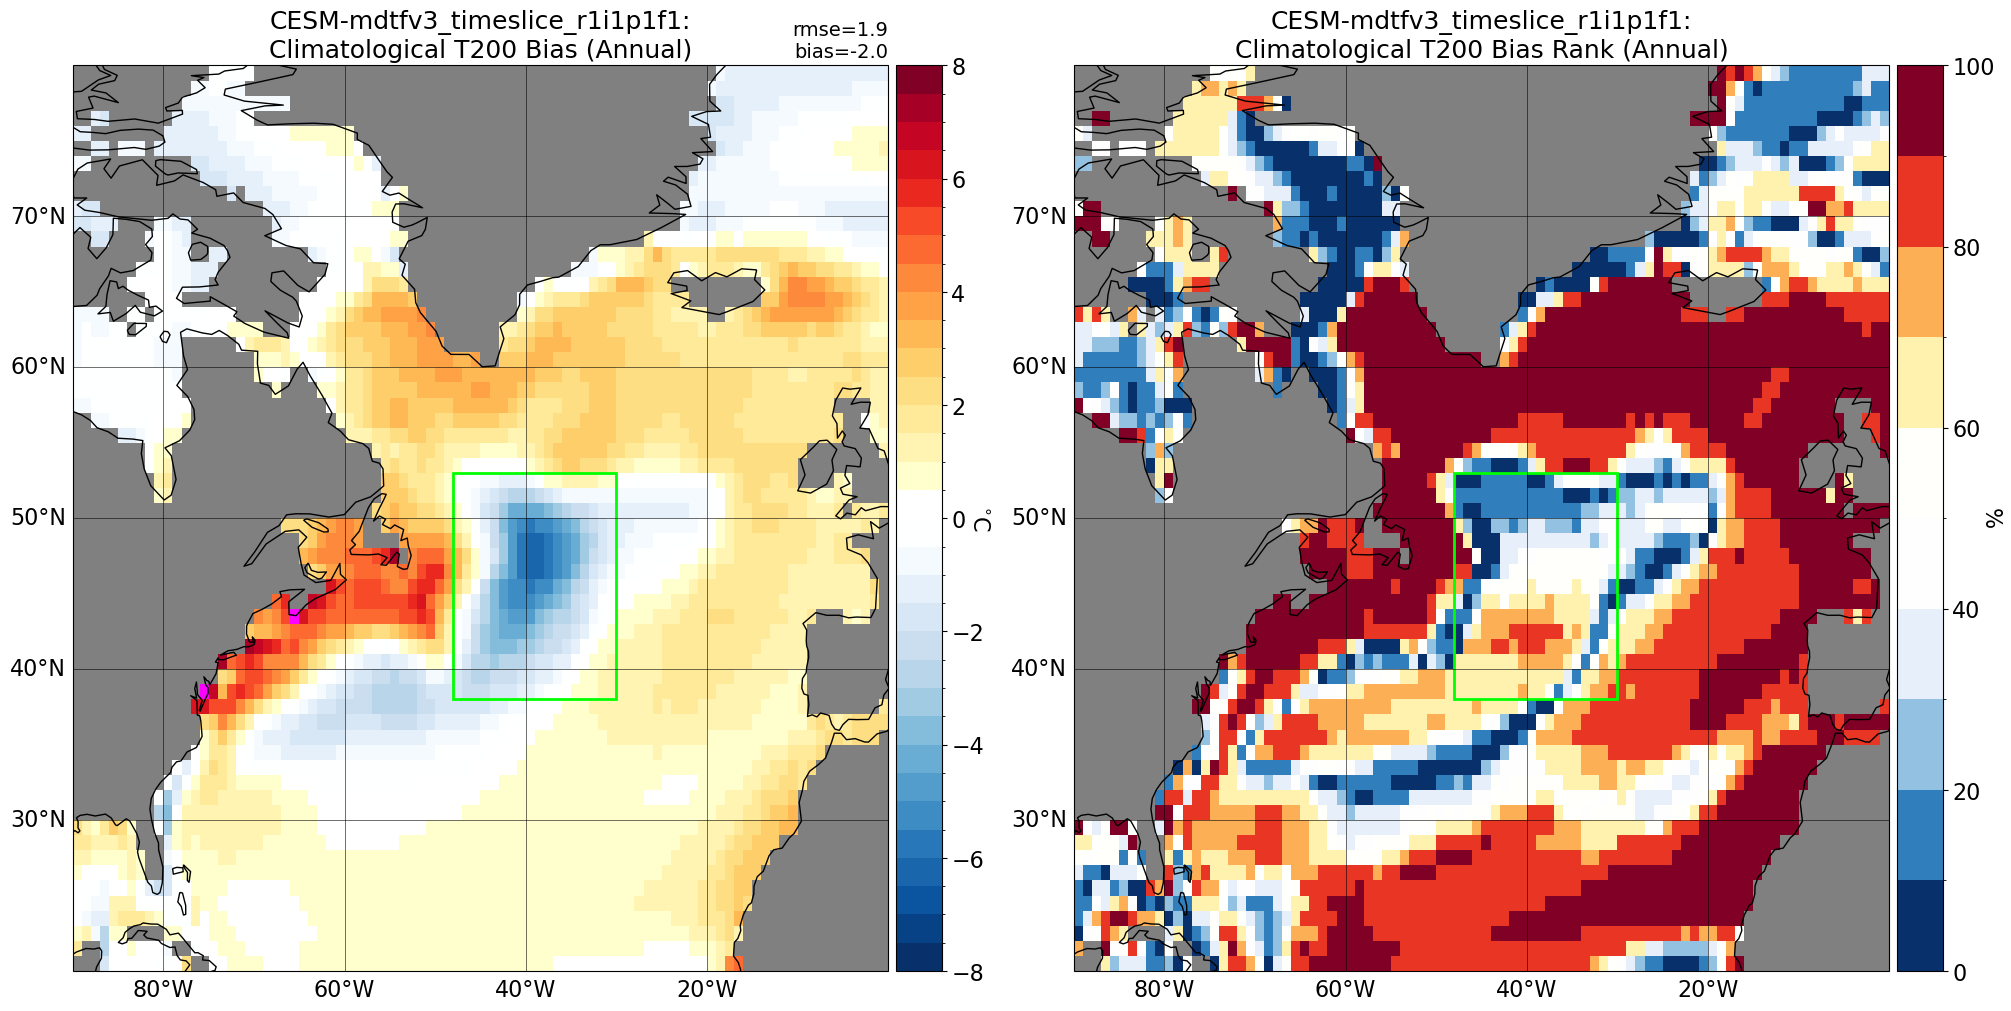

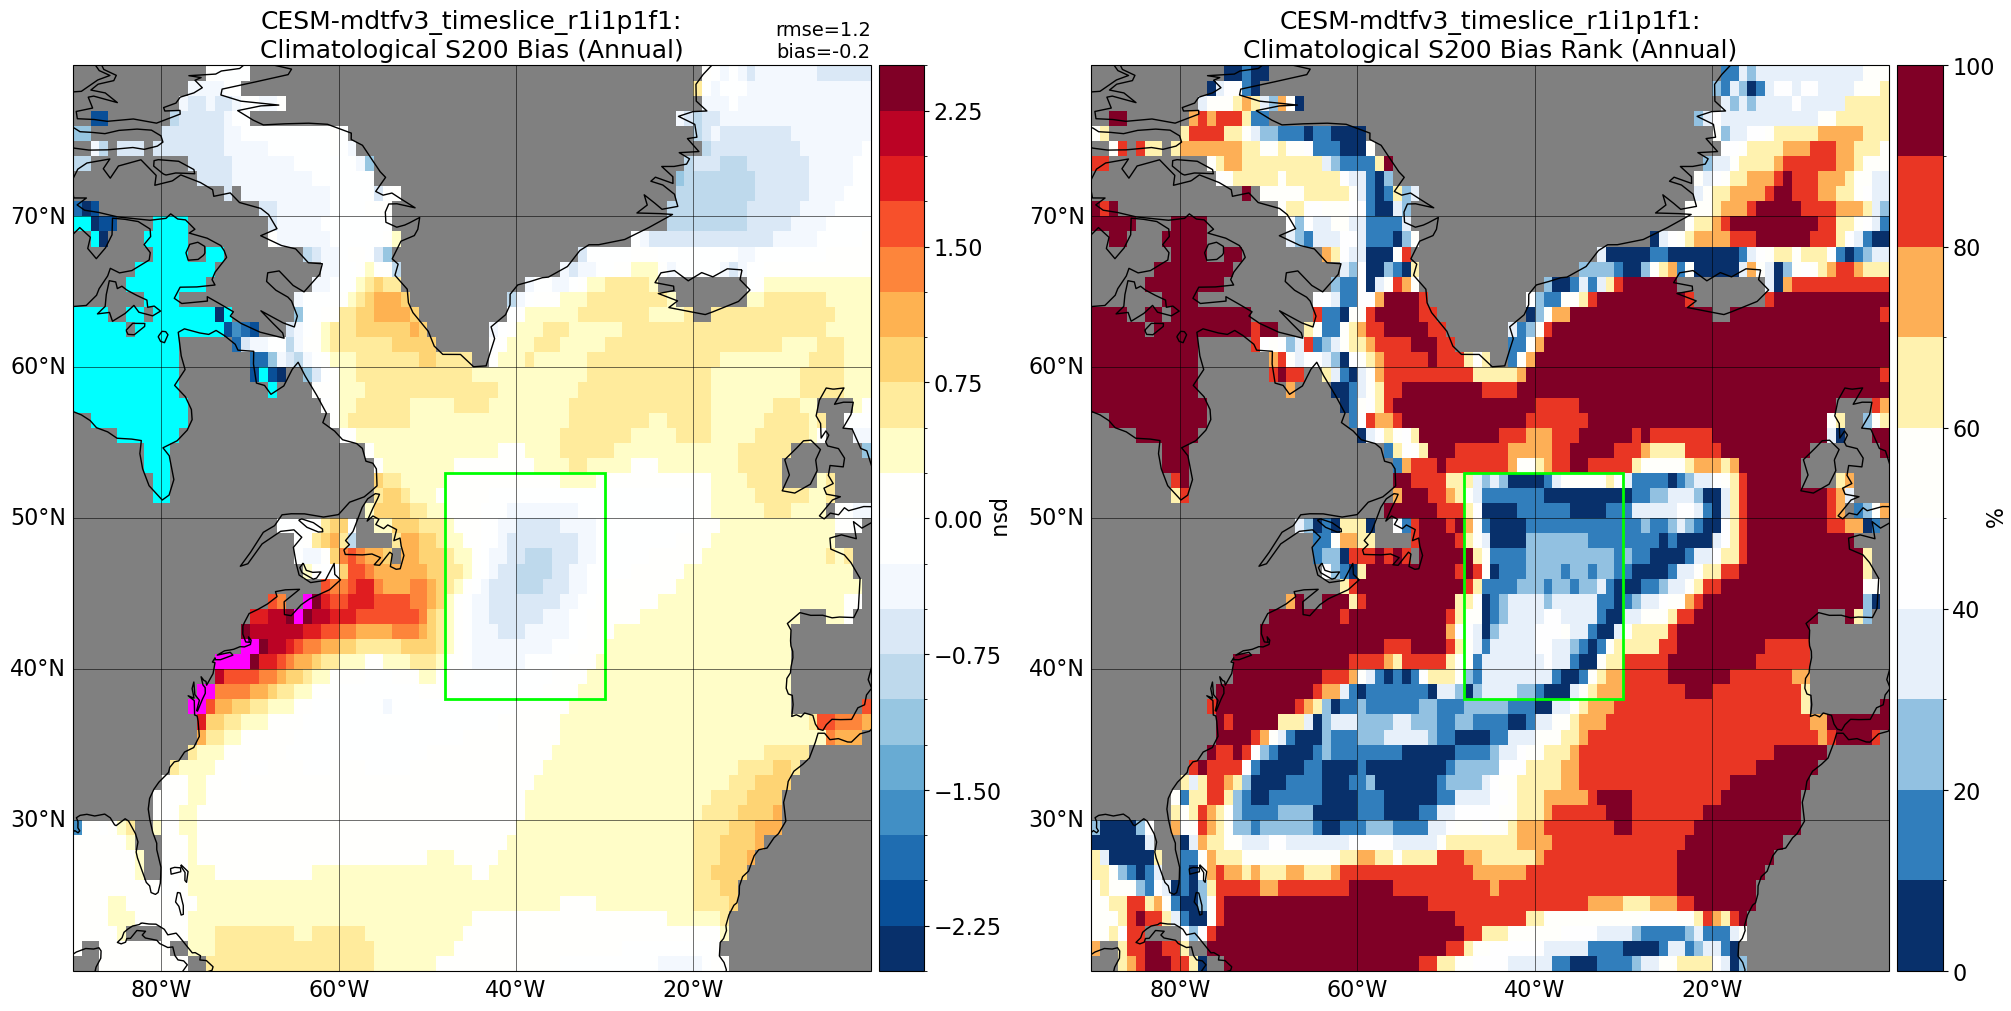

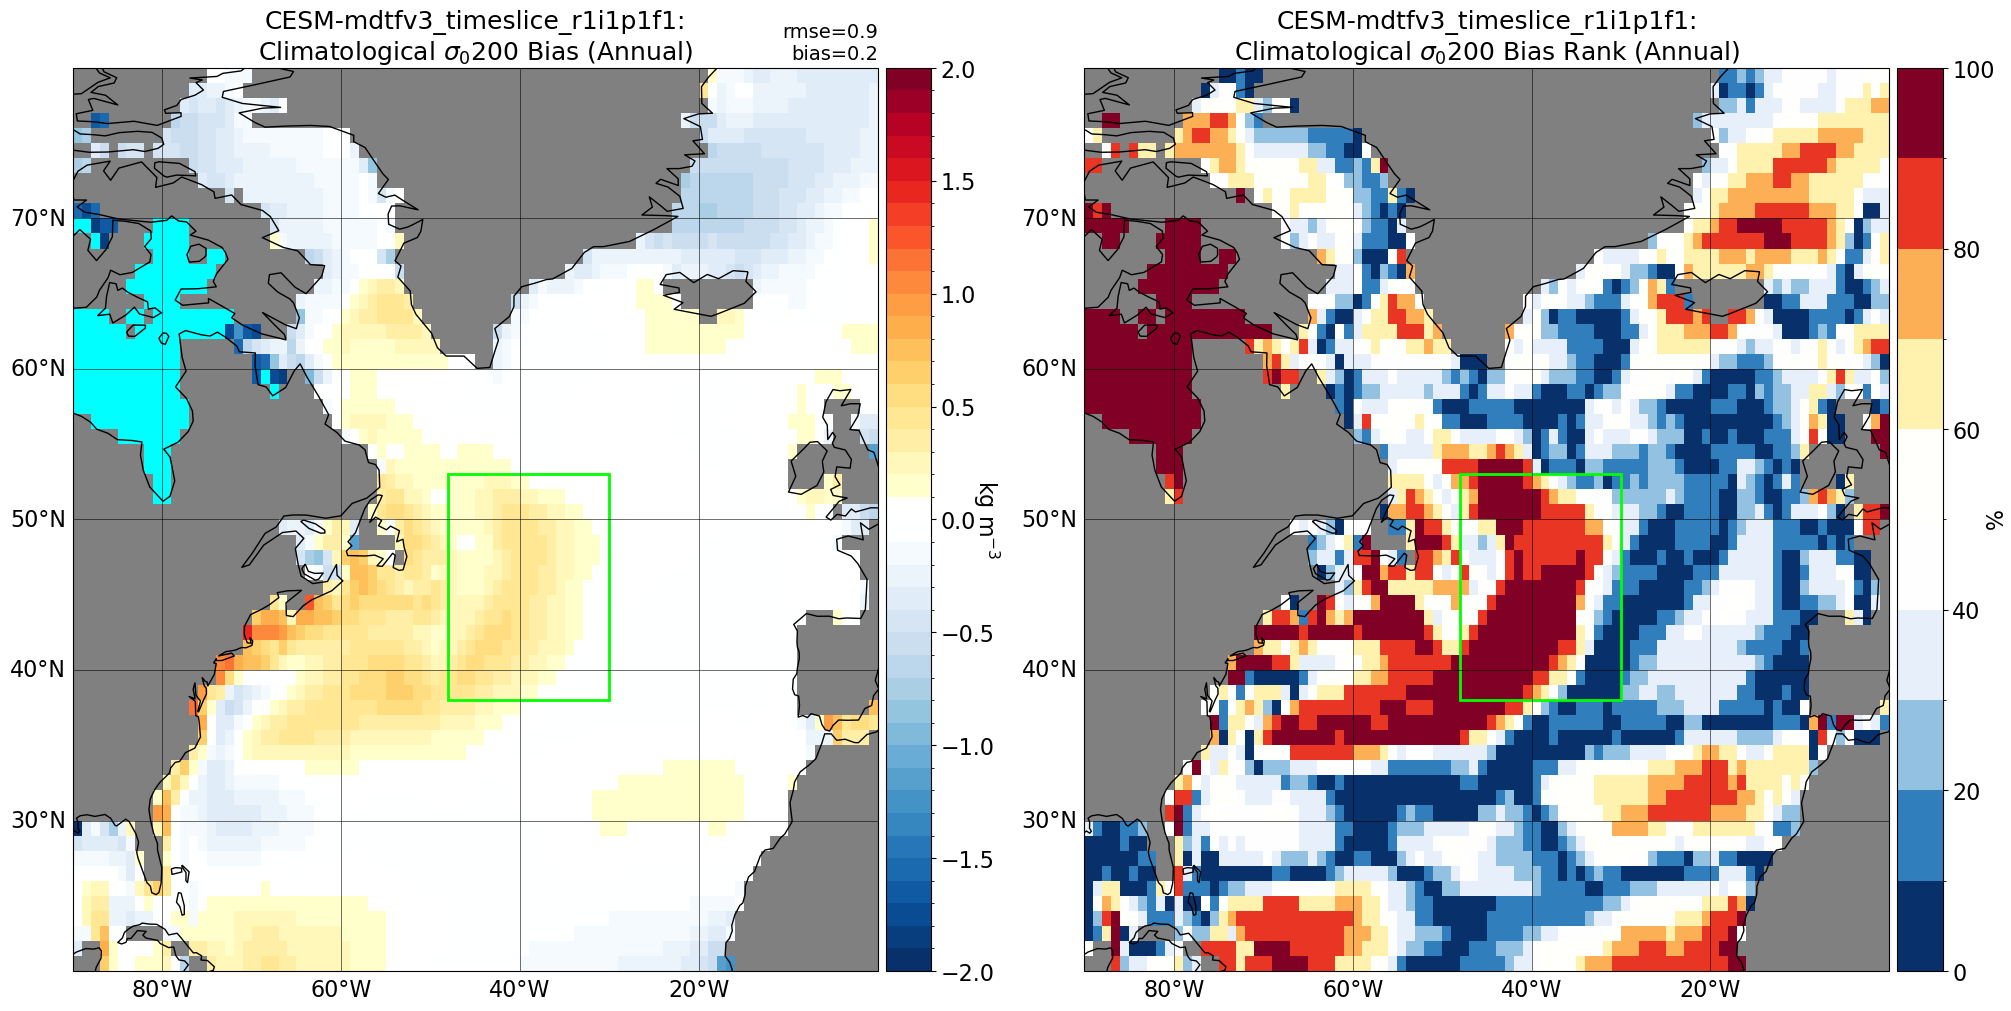

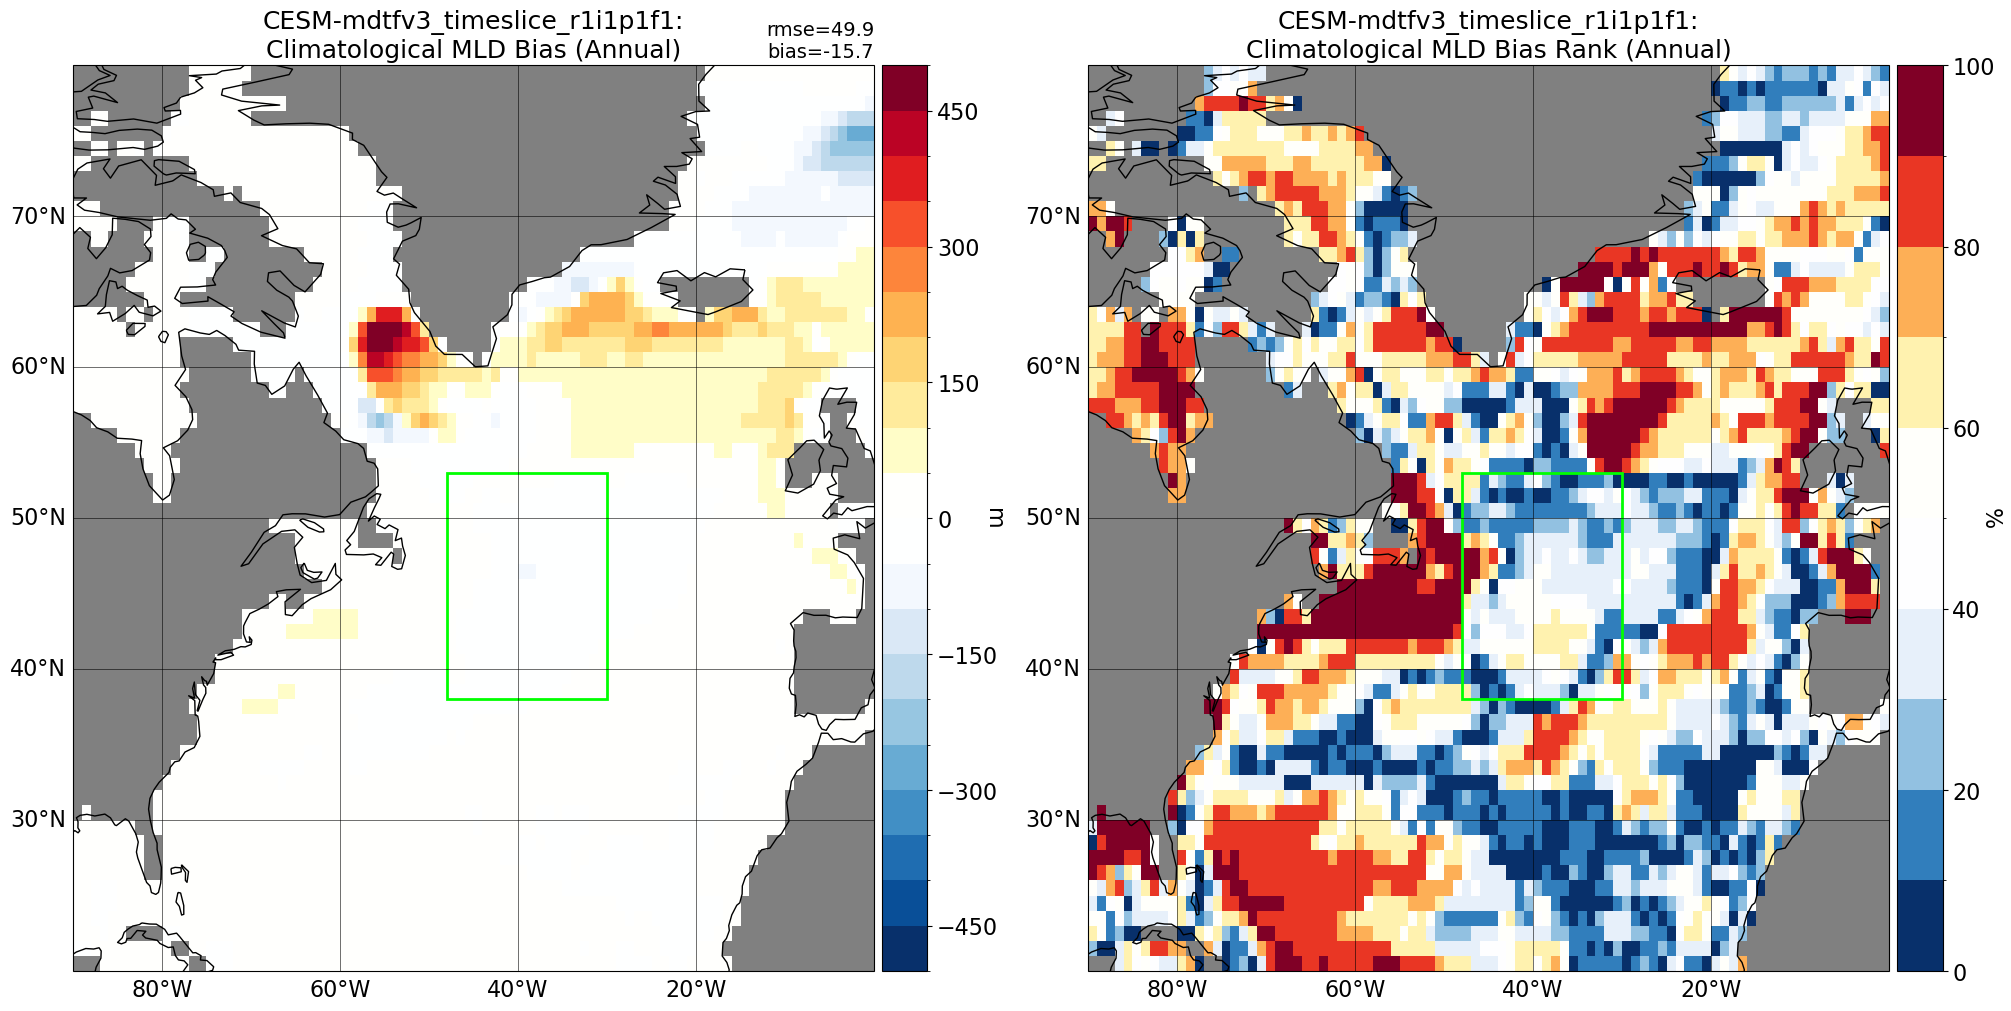

In [27]:
outmod_dir = os.path.join(os.environ['WORK_DIR'], 'model')
Path(outmod_dir).mkdir(parents=True, exist_ok=True)

region = opts['plot_region']
focus  = opts['focus_region']
month  = opts['plot_month']

ds_t200 = POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'thetao_zavg',
                                          region=region, focus_region=focus, month=month,
                                          save=True, savedir=outmod_dir)
ds_s200 = POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'so_zavg',
                                          region=region, focus_region=focus, month=month,
                                          save=True, savedir=outmod_dir)
POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'sigma0_zavg',
                                 region=region, focus_region=focus, month=month,
                                 save=True, savedir=outmod_dir)
POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'mld',
                                 region=region, focus_region=focus, month=month,
                                 save=True, savedir=outmod_dir)

### Scatter plot of θ vs S biases

Compact summary of where θ and S biases are large together.

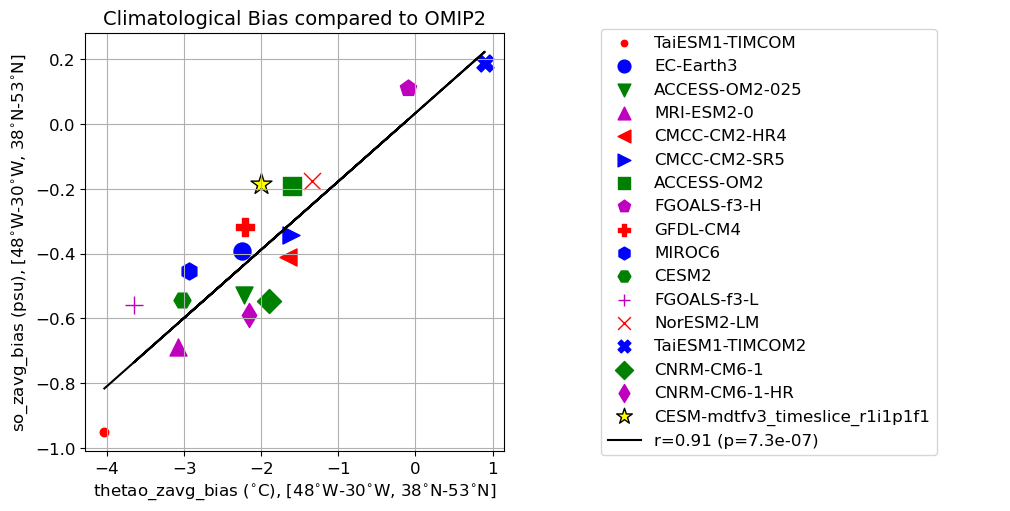

In [28]:
POD_utils.ScatterPlot_Error(
    ds_t200, 'thetao_zavg_bias',
    ds_s200, 'so_zavg_bias',
    model_name,
    save=False, savedir=outmod_dir,
)

### WMT lines vs OMIP benchmarks (by region)

Compare modeled surface-forced WMT against observation-based decomposed benchmarks (`obs_wmt_sigma2_1982-2009_spna_decomp_mean.nc`).

WMT benchmark vars: ['heat', 'wmt', 'freshwater']


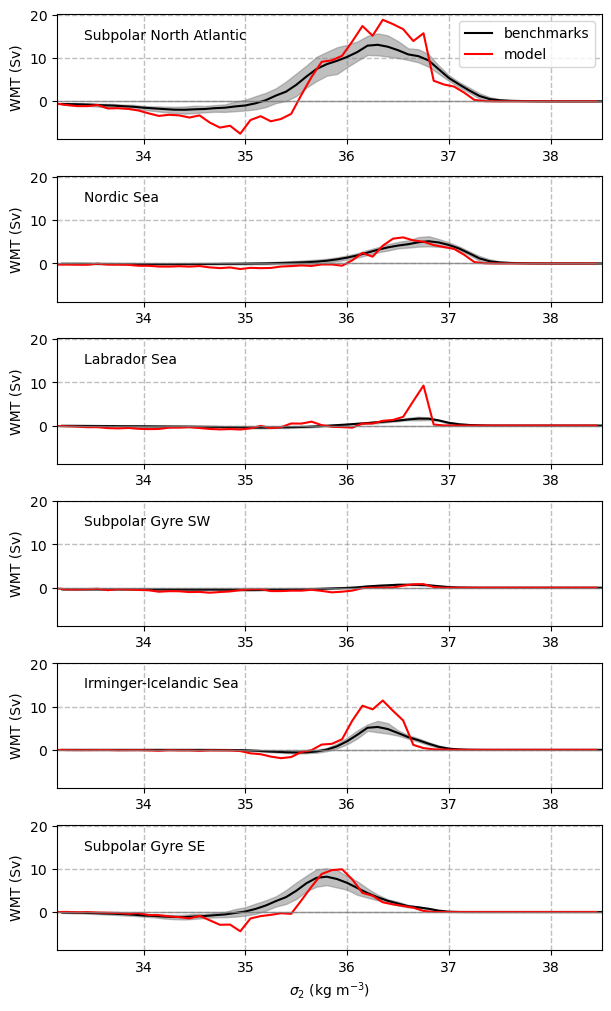

In [29]:
ds_wmt_benchmarks = xr.open_dataset(
    os.path.join(os.environ['OBS_DATA'], 'obs_wmt_sigma2_1982-2009_spna_decomp_mean.nc')
)
print('WMT benchmark vars:', list(ds_wmt_benchmarks.data_vars))

POD_utils.wmt_plot_byregion(
    ds_wmt_benchmarks, ds_wmt_lines, sigma_classes,
    save=False, savedir=outmod_dir,
)

### Density-flux maps at specified σ₂ classes

Maps of surface density flux into each water-mass class compared to observation-based decomposed benchmarks (`obs.maps_freq.sigma2.1982-2009_decomp_mean_1x1.nc`).

density-flux benchmark vars: ['heat', 'salt', 'wmt', 'wmt_freq']
correcting lon for dateline


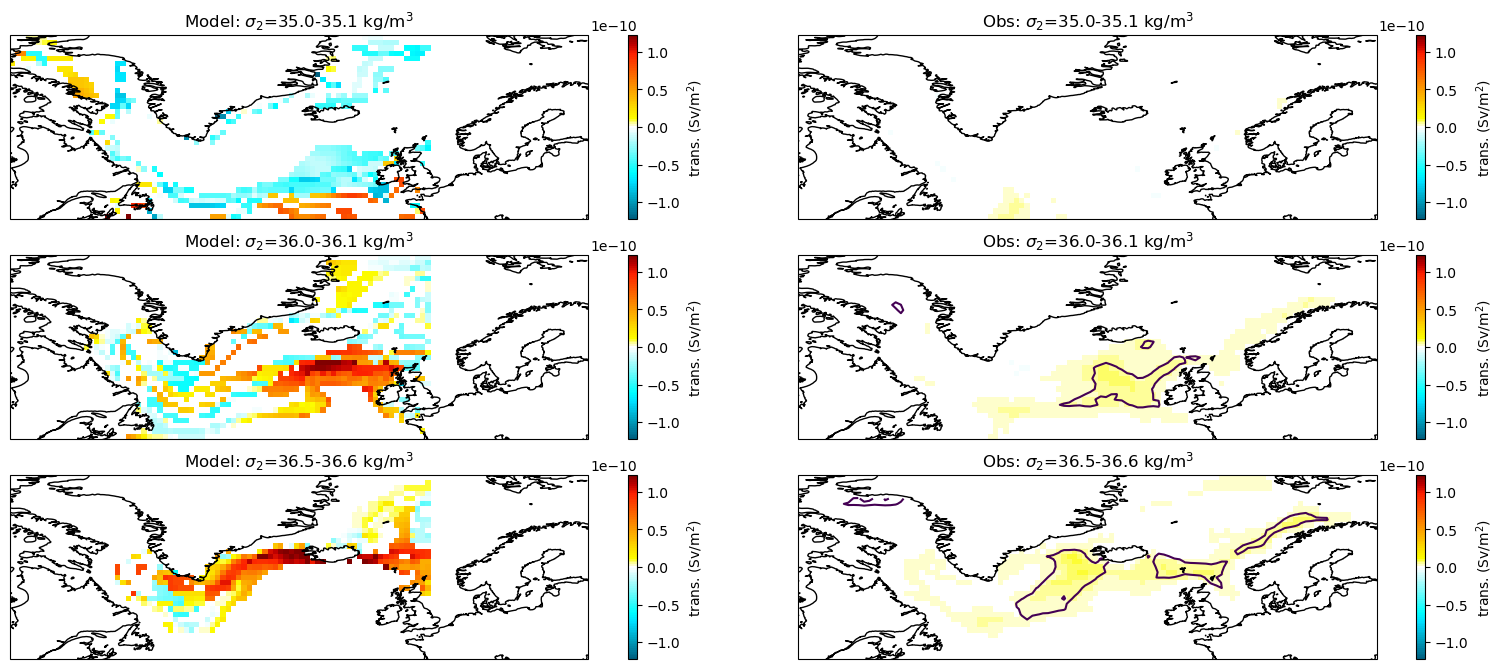

In [32]:
ds_dflux_benchmarks = xr.open_dataset(
    os.path.join(os.environ['OBS_DATA'], 'obs.maps_freq.sigma2.1982-2009_decomp_mean_1x1.nc')
)
print('density-flux benchmark vars:', list(ds_dflux_benchmarks.data_vars))

POD_utils.wmt_plot_maps(
    ds_dflux_benchmarks, ds_wmt_maps,
    ['time', 'x', 'y'],
    sigma_classes,
    save=False, savedir=outmod_dir,
)

### Atlantic AMOC streamfunction (σ₂ space)

Time-mean of Atlantic basin MOC (`region=1`, set by `basinmask` in `POD_utils.calculate_moc`) plotted as lat × σ₂. Positive (red) shows northward upper-cell flow; negative (blue) shows the southward deep cell. The typical CESM2 AMOC pattern is a positive cell at σ₂ < ~36.5 kg/m³ and a return cell below.

moc_atl dims:  {'sigma': 95, 'lat': 179}
moc_atl range: -5.147 to +26.121 Sv
sigma range:   26.10 to 37.97 kg/m^3
lat range:     -88.5 to 89.5
NaN fraction:  0.0%


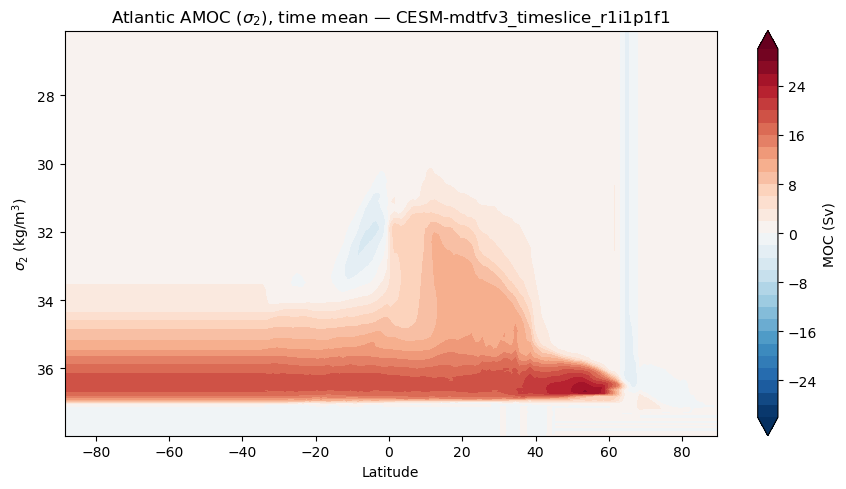

Atlantic upper-cell max MOC: 24.60 Sv (expect ~10-25 Sv for CESM2)


In [36]:
# Atlantic AMOC(sigma2) — time mean
import matplotlib.pyplot as plt

# region=1 is Atlantic+Arctic per basinmask attrs; take time mean and
# materialize (.compute) so matplotlib's contourf gets concrete values.
# Force dim order to (sigma, lat) so contourf gets z.shape == (len(y), len(x))
# regardless of the internal dim order calculate_moc produces.
moc_atl = ds_moc['MOC'].isel(region=1).mean('time').transpose('sigma', 'lat')

# Streamfunction type recorded by calculate_moc: 'Eulerian' (uo/vo) or
# 'residual' (umo/vmo). Used to label the plot correctly.
sf_type = ds_moc.attrs.get('streamfunction_type',
                           ds_moc['MOC'].attrs.get('streamfunction_type'))
sf_label = f'{sf_type} streamfunction' if sf_type else 'AMOC'

# sigma2_grid_96L anchors the lowest sigma_edge to 0 (a placeholder for
# "lighter than any physical seawater"). That anchor stretches the y-axis from
# 0 to 38 if left in, compressing the meaningful 26-38 range into a thin band
# and making the plot look empty. Slice to the physical range before plotting.
moc_atl = moc_atl.sel(sigma=slice(26, 38)).compute()

# Diagnostic prints: tell us whether the computation produced real values
print(f'moc_atl dims:  {dict(moc_atl.sizes)}')
print(f'moc_atl range: {float(moc_atl.min()):+.3f} to {float(moc_atl.max()):+.3f} Sv')
print(f'sigma range:   {float(moc_atl.sigma.min()):.2f} to {float(moc_atl.sigma.max()):.2f} kg/m^3')
print(f'lat range:     {float(moc_atl.lat.min()):.1f} to {float(moc_atl.lat.max()):.1f}')
print(f'NaN fraction:  {float(moc_atl.isnull().mean()):.1%}')

fig, ax = plt.subplots(figsize=(9, 5))
levels = np.arange(-30, 31, 2)  # Sv contours, 2 Sv spacing
cf = ax.contourf(
    moc_atl['lat'], moc_atl['sigma'], moc_atl,
    levels=levels, cmap='RdBu_r', extend='both',
)
ax.invert_yaxis()  # heavier water (larger sigma) downward visually
ax.set_xlabel('Latitude')
ax.set_ylabel(r'$\sigma_2$ (kg/m$^3$)')
ax.set_title(f'Atlantic {sf_label} ($\\sigma_2$), time mean — {model_name}')
fig.colorbar(cf, ax=ax, label='MOC (Sv)')
plt.tight_layout()
plt.show()

# Quick numeric sanity: AMOC max in upper cell should be O(10-25) Sv for CESM
upper_cell_max = float(moc_atl.where(moc_atl['sigma'] < 36.5).max())
print(f'Atlantic upper-cell max MOC: {upper_cell_max:.2f} Sv (expect ~10-25 Sv for CESM)')

### WMT + AMOC at 45°N (compensation diagnostic)

Three curves as functions of σ₂ for the Subpolar North Atlantic:

- **Obs WMT** mean across 8 benchmarks (black line) with the min/max spread shaded
- **Model WMT** integrated over the full SPNA (red line)
- **Model AMOC at 45°N** (blue line, time mean)

In steady state, mass conservation implies the AMOC streamfunction at 45°N approximately balances the surface-forced WMT integrated north of 45°N. Departures suggest model deficiencies in surface forcing, mixed-layer dynamics, or interior mixing.

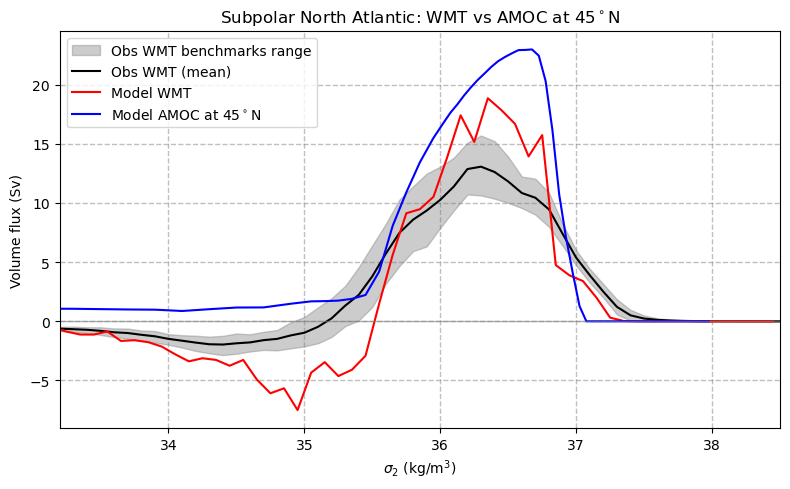

In [37]:
# WMT + AMOC at 45N compensation diagnostic
POD_utils.wmt_amoc_plot(
    ds_wmt_benchmarks, ds_wmt_lines, ds_moc,
    lat_target=45,
    region_name='Subpolar North Atlantic',
    save=False, savedir=outmod_dir,
)